# **Air Quality Index Prediction (AQI) using Machine Learning**

## **1. Problem Statement**
“The objective of this project is to predict Air Quality Index (AQI) using pollutant concentration data and identify the major pollutants contributing to air pollution. Additionally, the project aims to classify AQI into different categories and analyze trends over time”

In [1]:
!pip install folium --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded!")

All libraries loaded!


## **2. Data Collection**

In [2]:
df = pd.read_csv('/content/city_day.csv')


 "Dataset: city_day.csv — 29,531 rows, 16 columns, 26 Indian cities, 2015–2020. Source: CPCB via Kaggle."

## **3. Data Preprocessing**

In [3]:
print(df.shape)


(29531, 16)


In [4]:
print(df.head())

        City        Date  PM2.5  PM10     NO    NO2    NOx  NH3     CO    SO2  \
0  Ahmedabad  2015-01-01    NaN   NaN   0.92  18.22  17.15  NaN   0.92  27.64   
1  Ahmedabad  2015-01-02    NaN   NaN   0.97  15.69  16.46  NaN   0.97  24.55   
2  Ahmedabad  2015-01-03    NaN   NaN  17.40  19.30  29.70  NaN  17.40  29.07   
3  Ahmedabad  2015-01-04    NaN   NaN   1.70  18.48  17.97  NaN   1.70  18.59   
4  Ahmedabad  2015-01-05    NaN   NaN  22.10  21.42  37.76  NaN  22.10  39.33   

       O3  Benzene  Toluene  Xylene  AQI AQI_Bucket  
0  133.36     0.00     0.02    0.00  NaN        NaN  
1   34.06     3.68     5.50    3.77  NaN        NaN  
2   30.70     6.80    16.40    2.25  NaN        NaN  
3   36.08     4.43    10.14    1.00  NaN        NaN  
4   39.31     7.01    18.89    2.78  NaN        NaN  


In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  object 
 1   Date        29531 non-null  object 
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  object 
dtypes: float64(13), object(3)
memory usage: 3.6+ MB
None


In [6]:
print(df.describe())

              PM2.5          PM10            NO           NO2           NOx  \
count  24933.000000  18391.000000  25949.000000  25946.000000  25346.000000   
mean      67.450578    118.127103     17.574730     28.560659     32.309123   
std       64.661449     90.605110     22.785846     24.474746     31.646011   
min        0.040000      0.010000      0.020000      0.010000      0.000000   
25%       28.820000     56.255000      5.630000     11.750000     12.820000   
50%       48.570000     95.680000      9.890000     21.690000     23.520000   
75%       80.590000    149.745000     19.950000     37.620000     40.127500   
max      949.990000   1000.000000    390.680000    362.210000    467.630000   

                NH3            CO           SO2            O3       Benzene  \
count  19203.000000  27472.000000  25677.000000  25509.000000  23908.000000   
mean      23.483476      2.248598     14.531977     34.491430      3.280840   
std       25.684275      6.962884     18.133775    

In [7]:

print("Null values BEFORE cleaning:")
print(df.isnull().sum())


Null values BEFORE cleaning:
City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64


"Handling Missing Values"

In [8]:
df = df.drop(columns=['AQI_Bucket'])
df = df.dropna(subset=['AQI'])
df = df.drop(columns=['Xylene', 'NH3'])
df = df.drop(columns=['PM10'])


In [9]:
df.fillna(df.mean(numeric_only=True), inplace=True)

In [10]:
print("\nNull values AFTER cleaning:")
df.isnull().sum()


Null values AFTER cleaning:


,0
City,0
Date,0
PM2.5,0
NO,0
NO2,0
NOx,0
CO,0
SO2,0
O3,0
Benzene,0


In [11]:
# Log-transform to handle skewed AQI distribution
df['AQI_log'] = np.log1p(df['AQI'])
print("\nAQI_log column added. Shape:", df.shape)


AQI_log column added. Shape: (24850, 13)


## **4. EDA (Exploratory Data Analysis)**
- Distribution
- Correlation
- Time-based analysis
- Year-wise trend
- AQI category pie chart

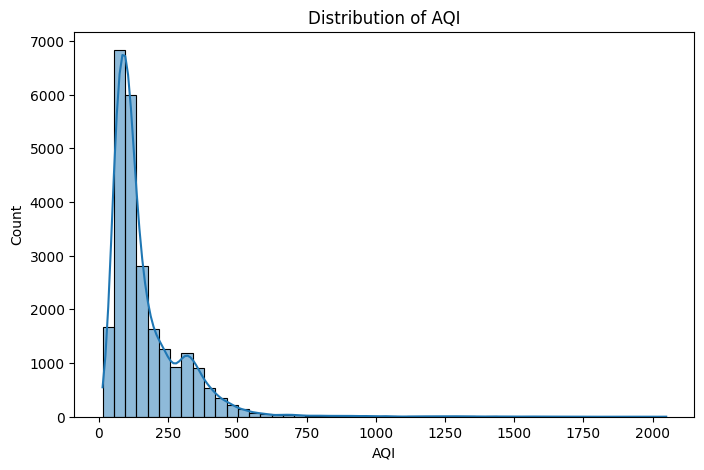

In [12]:
# --- Distribution of AQI   ---
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df['AQI'], bins=50, kde=True)
plt.title("Distribution of AQI")
plt.show()

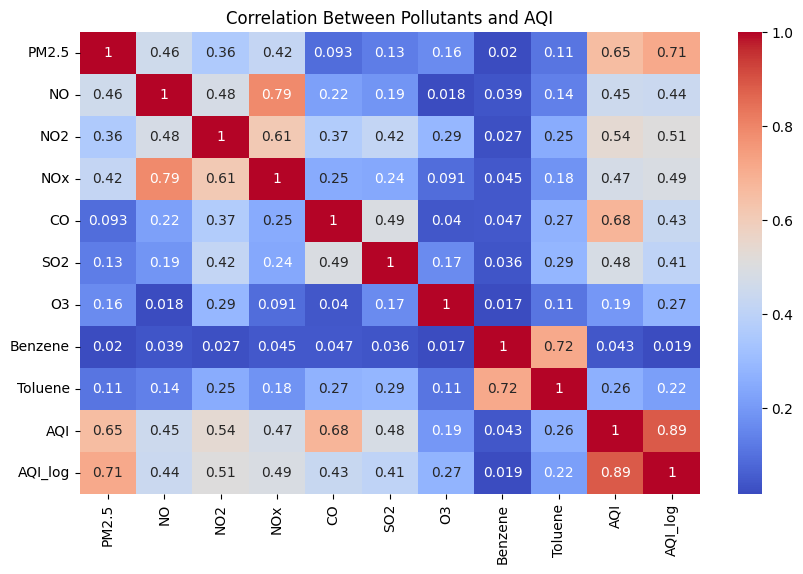

In [13]:
# --- Correlation ---
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Between Pollutants and AQI")
plt.show()

In [14]:
# --- Time Based Analysis ---
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month

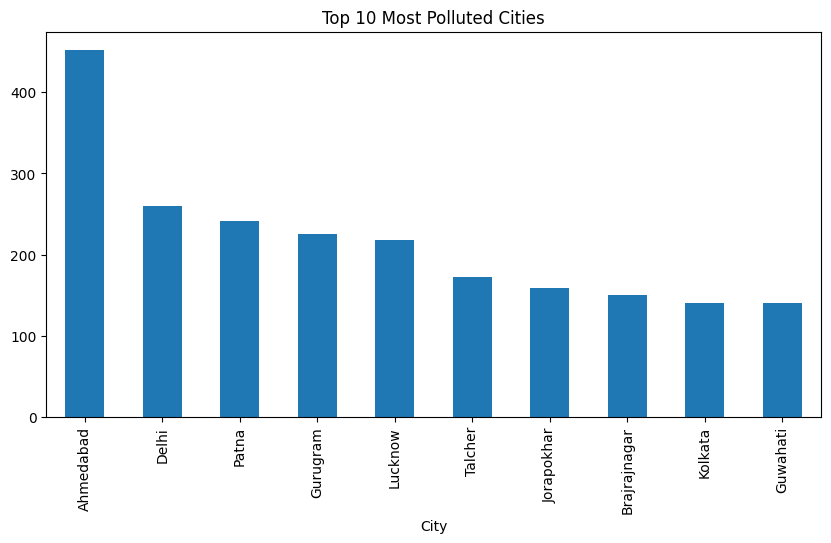

In [15]:
city_aqi = df.groupby('City')['AQI'].mean().sort_values(ascending=False)

city_aqi.head(10).plot(kind='bar', figsize=(10,5))
plt.title("Top 10 Most Polluted Cities")
plt.show()

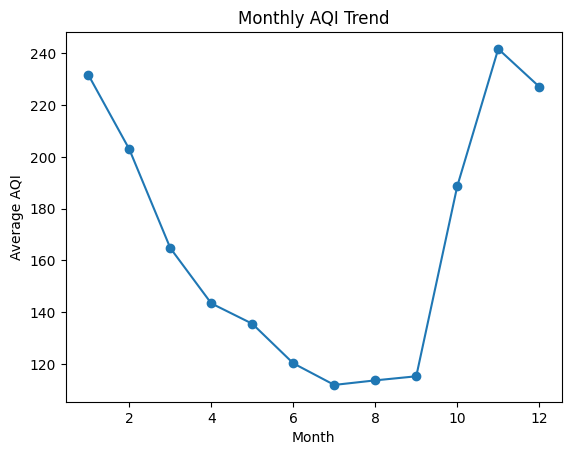

In [16]:
import matplotlib.pyplot as plt

monthly_aqi = df.groupby('Month')['AQI'].mean()

monthly_aqi.plot(marker='o')
plt.title("Monthly AQI Trend")
plt.xlabel("Month")
plt.ylabel("Average AQI")
plt.show()

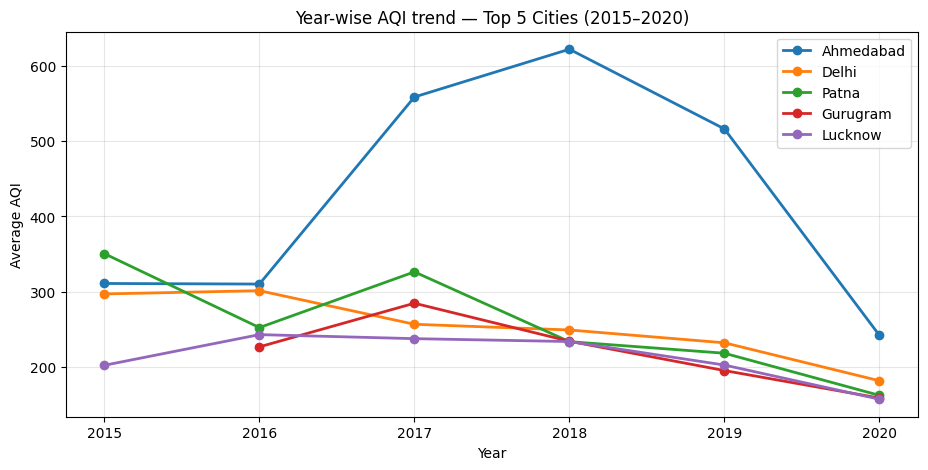

In [17]:
#  --- Year-wise trend ---
df['Year'] = pd.to_datetime(df['Date']).dt.year
top5 = df.groupby('City')['AQI'].mean()\
         .sort_values(ascending=False).head(5).index
yearly = df[df['City'].isin(top5)]\
           .groupby(['City','Year'])['AQI'].mean().reset_index()
plt.figure(figsize=(11,5))
for city in top5:
    d = yearly[yearly['City']==city]
    plt.plot(d['Year'], d['AQI'], marker='o', label=city, linewidth=2)
plt.title('Year-wise AQI trend — Top 5 Cities (2015–2020)')
plt.xlabel('Year'); plt.ylabel('Average AQI')
plt.legend(); plt.grid(alpha=0.3); plt.show()
plt.show()


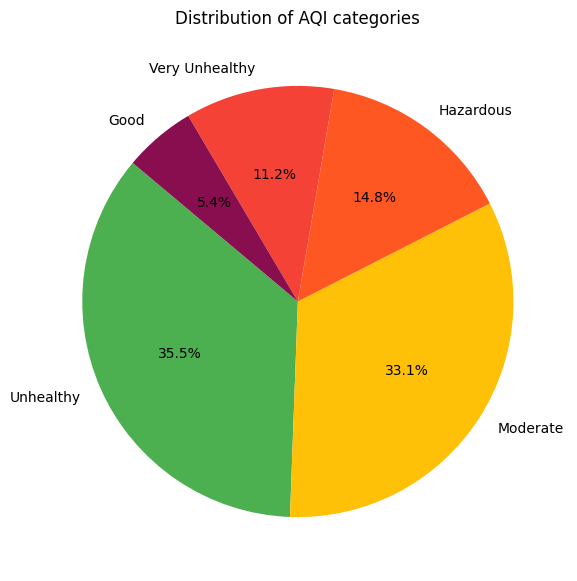

In [18]:
# ---  AQI category pie chart ---
def cat(a):
    if a<=50: return 'Good'
    elif a<=100: return 'Moderate'
    elif a<=200: return 'Unhealthy'
    elif a<=300: return 'Very Unhealthy'
    else: return 'Hazardous'
df['AQI_Cat'] = df['AQI'].apply(cat)
counts = df['AQI_Cat'].value_counts()
colors = ['#4CAF50','#FFC107','#FF5722','#F44336','#880E4F']
plt.figure(figsize=(7,7))
plt.pie(counts, labels=counts.index, autopct='%1.1f%%',
        colors=colors[:len(counts)], startangle=140)
plt.title('Distribution of AQI categories')
plt.show()

## **5. Regression Model**
   - Linear, Random Forest, Gradient Boost
   - Evaluation
   - Model comparison
   - Residual analysis
   - Feature importance

In [19]:
X = df[['PM2.5','NO','NO2','NOx','CO','SO2','O3','Benzene','Toluene']]
y = df['AQI']

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [21]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [22]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)



In [23]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(random_state=42)
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)


In [24]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

print("LR R2:", r2_score(y_test, y_pred_lr))
print("LR RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))

LR R2: 0.7899845800615594
LR RMSE: 62.012876072165746


In [25]:
print("RF R2:", r2_score(y_test, y_pred_rf))
print("RF RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))

RF R2: 0.8934793546805389
RF RMSE: 44.16448562572862


In [26]:
print("GB R2:", r2_score(y_test, y_pred_gb))
print("GB RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_gb)))

GB R2: 0.8745841376006036
GB RMSE: 47.921733173871246


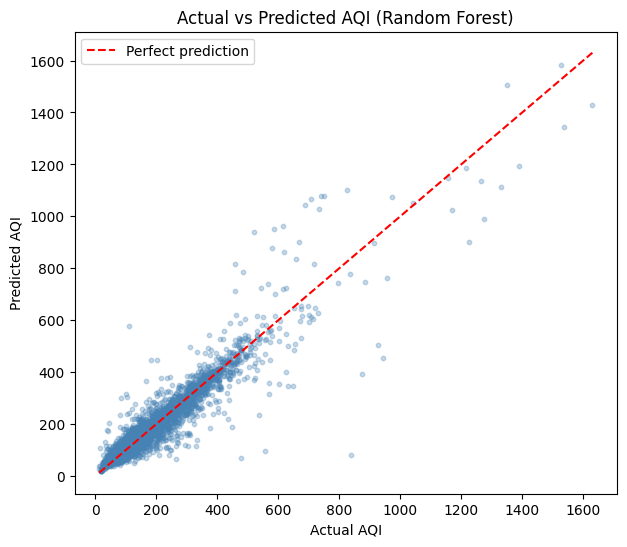

In [27]:
# --- After evaluation metrics: Actual vs Predicted ---
plt.figure(figsize=(7,6))
plt.scatter(y_test, y_pred_rf, alpha=0.3, color='steelblue', s=10)
mn, mx = y_test.min(), y_test.max()
plt.plot([mn,mx],[mn,mx],'r--', linewidth=1.5, label='Perfect prediction')
plt.xlabel('Actual AQI'); plt.ylabel('Predicted AQI')
plt.title('Actual vs Predicted AQI (Random Forest)')
plt.legend(); plt.show()



CV R² scores: [0.402 0.832 0.848 0.791 0.855]
Mean R²: 0.7456 | Std: 0.1733


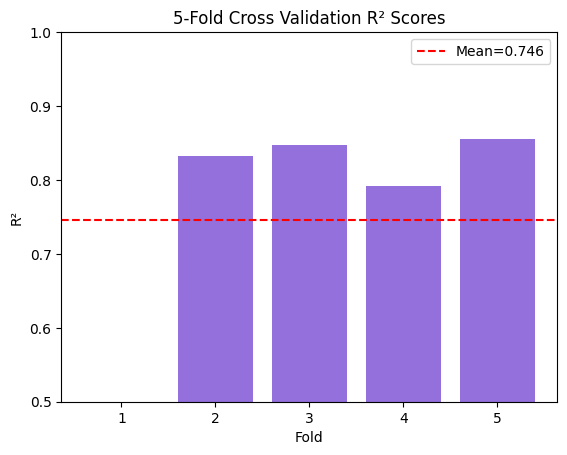

In [28]:
# --- Cross-validation ---
from sklearn.model_selection import cross_val_score
cv = cross_val_score(rf, X, y, cv=5, scoring='r2')
print(f"CV R² scores: {np.round(cv,3)}")
print(f"Mean R²: {cv.mean():.4f} | Std: {cv.std():.4f}")
plt.bar(range(1,6), cv, color='mediumpurple')
plt.axhline(cv.mean(), color='red', linestyle='--',
            label=f'Mean={cv.mean():.3f}')
plt.title('5-Fold Cross Validation R² Scores')
plt.xlabel('Fold'); plt.ylabel('R²')
plt.legend(); plt.ylim(0.5,1.0); plt.show()

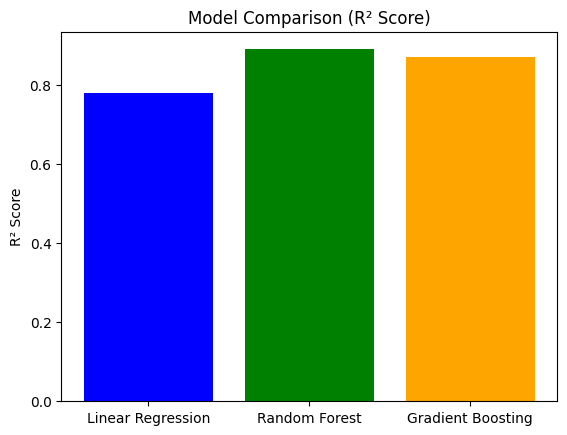

In [29]:
models = ['Linear Regression', 'Random Forest', 'Gradient Boosting']
r2_scores = [0.78, 0.89, 0.87]

plt.bar(models, r2_scores, color=['blue','green','orange'])
plt.title("Model Comparison (R² Score)")
plt.ylabel("R² Score")
plt.show()

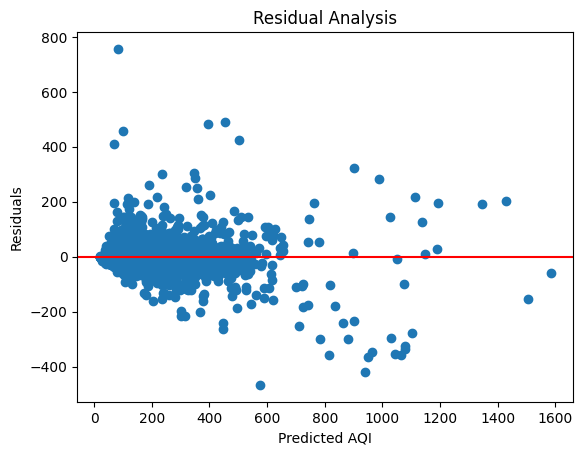

In [30]:
residuals = y_test - y_pred_rf

plt.scatter(y_pred_rf, residuals)
plt.axhline(y=0, color='red')
plt.xlabel("Predicted AQI")
plt.ylabel("Residuals")
plt.title("Residual Analysis")
plt.show()

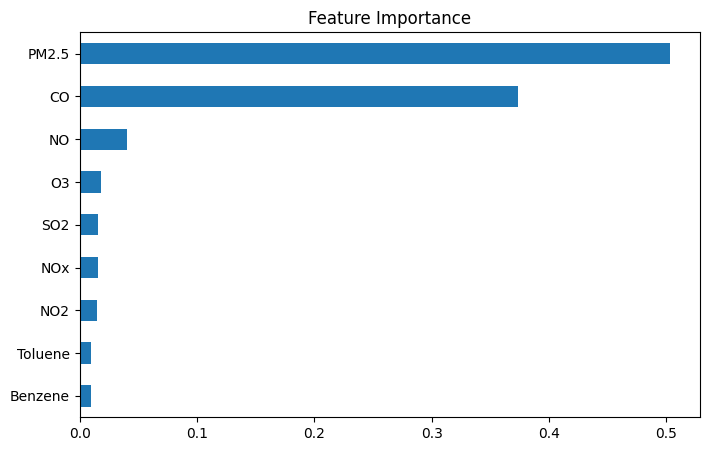

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

feature_names = ['PM2.5','NO','NO2','NOx','CO','SO2','O3','Benzene','Toluene']

importance = pd.Series(rf.feature_importances_, index=feature_names)

importance.sort_values().plot(kind='barh', figsize=(8,5))
plt.title("Feature Importance")
plt.show()

##Feature Importance
PM2.5 is the most significant contributor to AQI

CO is the second most important factor

Other pollutants have relatively lower impact

## **6. Classification Model**
   - Accuracy
   - Confusion matrix

In [32]:
def categorize_aqi(aqi):
    if aqi <= 50: return "Good"
    elif aqi <= 100: return "Moderate"
    elif aqi <= 200: return "Poor"
    elif aqi <= 300: return "Very Poor"
    else: return "Severe"

df['AQI_Category'] = df['AQI'].apply(categorize_aqi)

In [33]:
X = df[['PM2.5','NO','NO2','NOx','CO','SO2','O3','Benzene','Toluene']]
y = df['AQI_Category']

In [34]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [36]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

In [37]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7993963782696177
              precision    recall  f1-score   support

           0       0.79      0.60      0.68       282
           1       0.80      0.84      0.82      1655
           2       0.79      0.82      0.80      1745
           3       0.90      0.88      0.89       733
           4       0.69      0.61      0.65       555

    accuracy                           0.80      4970
   macro avg       0.79      0.75      0.77      4970
weighted avg       0.80      0.80      0.80      4970



##Confusion Matrix Analysis

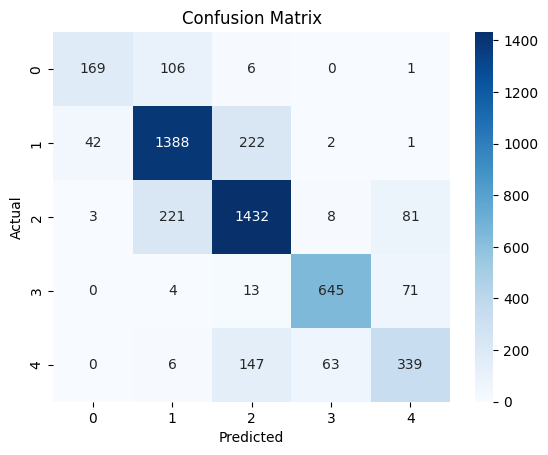

In [38]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## **7. Conclusion**
This project successfully predicts AQI using machine learning techniques. Ensemble models like Random Forest achieved the best performance, highlighting non-linear relationships between pollutants and air quality. Feature importance analysis identified PM2.5 and CO as major contributors. Time-based analysis revealed seasonal pollution patterns, while classification models effectively categorized AQI levels. Overall, the project provides meaningful insights into air pollution and demonstrates the practical application of machine learning in environmental analysis.

In [39]:
import pickle

# Save model
pickle.dump(rf, open('aqi_model.pkl', 'wb'))

print("Model saved successfully!")

Model saved successfully!


In [40]:
from google.colab import files
files.download('aqi_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>